In [47]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.stattools import adfuller

This code imports the essential Python libraries required for data preprocessing, visualization, machine learning model training, model evaluation, hyperparameter tuning, and time series analysis, while suppressing warning messages for cleaner output.

In [48]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")
print(df.head())
print("shape", df.shape)
print("\ncolumns:")
print(df.columns.tolist())
print("\ninfo:")
df.info()
print("\ndescribe")
display(df.describe())

   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations  
0         1863.42  Interpolated (Month)              12207  
1          249.46    Official (Quarter)               7640  
2          

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


This code loads the dataset from a CSV file, displays the first few rows, prints the dataset's shape and column names, provides information about data types and missing values, and generates descriptive statistics to understand the dataset.

In [49]:
print("missing values")
print(df.isnull().sum(),"\n")
print("duplicate rows")
print(df.duplicated().sum())

missing values
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64 

duplicate rows
0


This code checks the dataset for missing values in each column and counts the number of duplicate rows to assess data quality before preprocessing.

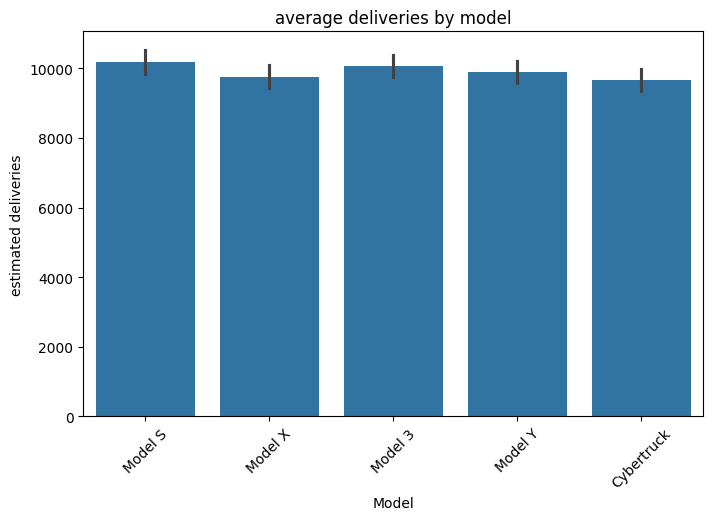

In [51]:
plt.figure(figsize=(8,5))
sns.barplot(
    data = df,
    x = 'Model',
    y = 'Estimated_Deliveries',
    estimator = np.mean
)
plt.title('average deliveries by model')
plt.xlabel('Model')
plt.ylabel('estimated deliveries')
plt.xticks(rotation=45)
plt.show()

This code creates a bar chart showing the average estimated deliveries for each Tesla model using Seaborn, with rotated x-axis labels for better readability and appropriate chart titles and axis labels.

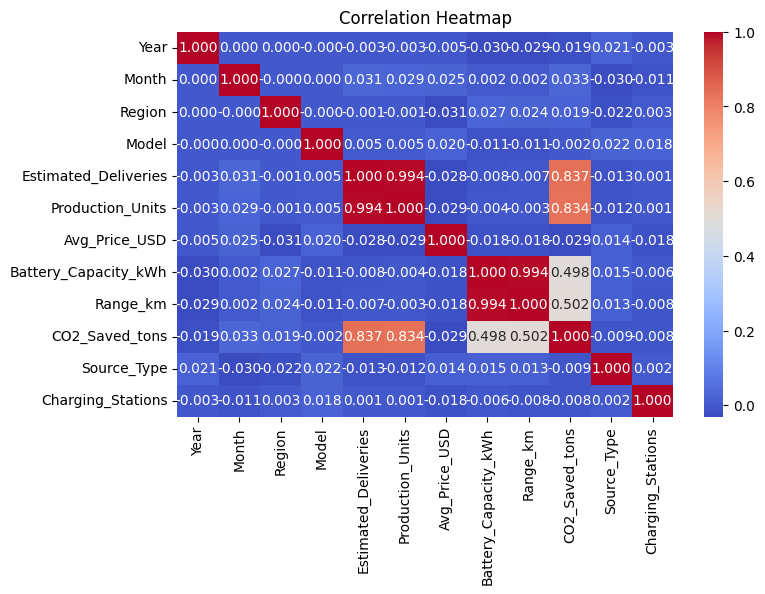

In [52]:
from numpy._core import numeric
temp = df.copy()
temp['Region'] = LabelEncoder().fit_transform(temp['Region'])
temp['Model'] = LabelEncoder().fit_transform(temp['Model'])
temp['Source_Type'] = LabelEncoder().fit_transform(temp['Source_Type'])
plt.figure(figsize=(8,5))
sns.heatmap(
    temp.corr(numeric_only = True),
    annot = True,
    fmt = '.3f',
    cmap = 'coolwarm'
)
plt.title('Correlation Heatmap')
plt.show()

This code creates a copy of the dataset, encodes categorical columns into numerical values using LabelEncoder, computes the correlation matrix, and visualizes it as a heatmap with correlation coefficients to identify relationships between variables.

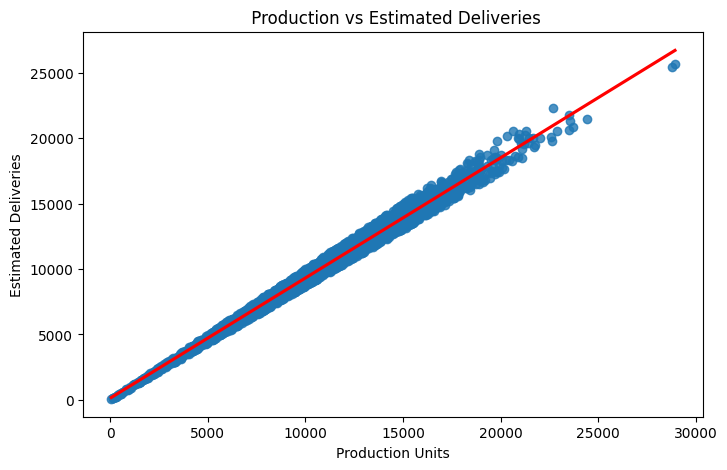

Correlation =  0.9942343488939529


In [53]:
plt.figure(figsize=(8,5))
sns.regplot(
    data = df,
    x = 'Production_Units',
    y = 'Estimated_Deliveries',
    line_kws={'color': 'red'}
)
plt.title(' Production vs Estimated Deliveries')
plt.xlabel('Production Units')
plt.ylabel('Estimated Deliveries')
plt.show()
corr = df['Production_Units'].corr(df['Estimated_Deliveries'])
print("Correlation = ", corr)

This code creates a regression plot to visualize the relationship between production units and estimated deliveries, adds a best-fit regression line, and calculates the correlation coefficient to measure the strength of their linear relationship.

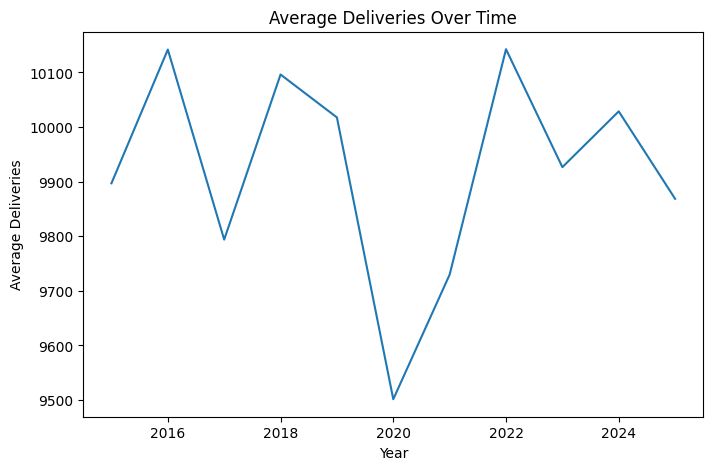

In [54]:
trend = df.groupby('Year')['Estimated_Deliveries'].mean().reset_index()
plt.figure(figsize=(8,5))
sns.lineplot(
    data=trend,
    x='Year',
    y='Estimated_Deliveries'
)
plt.title("Average Deliveries Over Time")
plt.xlabel("Year")
plt.ylabel("Average Deliveries")
plt.show()

This code groups the data by year, calculates the average estimated deliveries for each year, and visualizes the delivery trend over time using a line chart.

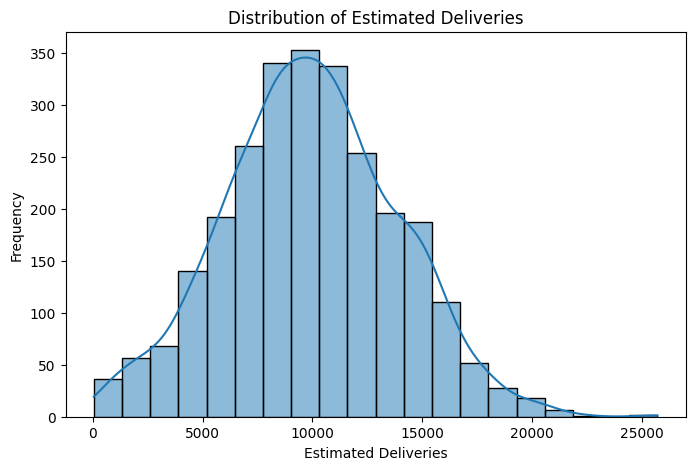

In [55]:
plt.figure(figsize=(8,5))
sns.histplot(
    df['Estimated_Deliveries'],
    bins = 20,
    kde = True
)
plt.title('Distribution of Estimated Deliveries')
plt.xlabel('Estimated Deliveries')
plt.ylabel('Frequency')
plt.show()

This code creates a histogram with a kernel density estimate (KDE) to visualize the distribution of estimated deliveries, showing the frequency and overall pattern of the data.

In [56]:
encoder_obj = LabelEncoder()
cat_features = ['Region', 'Model', 'Source_Type']
for feature in cat_features:
    df[feature] = encoder_obj.fit_transform(df[feature])
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722


This code encodes the categorical columns (Region, Model, and Source_Type) into numerical values using LabelEncoder, making the dataset suitable for machine learning models, and then displays the first few rows of the updated dataset.

In [57]:
df['prev_month_delivery'] = df['Estimated_Deliveries'].shift(1)
df['prev_month_delivery'].fillna(
    df['prev_month_delivery'].median(),
    inplace=True
)

This code creates a previous month's delivery feature by shifting the Estimated_Deliveries column by one row and fills the missing value in the first row with the median of the shifted values to avoid null values.

In [58]:
df['delivery_avg_window'] = (
    df['Estimated_Deliveries']
    .rolling(window=3)
    .mean()
)
df['delivery_avg_window'].fillna(
    df['delivery_avg_window'].median(),
    inplace=True
)

This code creates a 3-month rolling average feature for estimated deliveries to capture short-term trends and fills the initial missing values with the median of the rolling averages.

In [59]:
print(
    df[
        ['Estimated_Deliveries',
         'prev_month_delivery',
         'delivery_avg_window']
    ].head()
)

   Estimated_Deliveries  prev_month_delivery  delivery_avg_window
0                 17646               9860.0          9898.333333
1                  3797              17646.0          9898.333333
2                  8411               3797.0          9951.333333
3                  6555               8411.0          6254.333333
4                 12374               6555.0          9113.333333


This code displays the first few rows of the Estimated_Deliveries, previous month's delivery, and 3-month rolling average columns to verify the newly created features.

In [60]:
target_column = df['Estimated_Deliveries']
input_features = df.drop(
    columns=['Estimated_Deliveries']
)

This code separates the dataset into target and input features, where Estimated_Deliveries is assigned as the target variable and all remaining columns are used as input features for model training.

In [61]:
cutoff_point = int(len(df) * 0.80)
X_train = input_features.iloc[:cutoff_point]
X_test = input_features.iloc[cutoff_point:]
y_train = target_column.iloc[:cutoff_point]
y_test = target_column.iloc[cutoff_point:]

This code splits the dataset into training (80%) and testing (20%) sets using sequential indexing, preserving the data order for model training and evaluation.

In [62]:
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)
linear_predictions = baseline_model.predict(X_test)

This code initializes a Linear Regression model, trains it using the training dataset, and generates predictions for the test dataset.

In [63]:
mae_score = mean_absolute_error(y_test, linear_predictions)
rmse_score = np.sqrt(mean_squared_error(y_test, linear_predictions))
r2_value = r2_score(y_test, linear_predictions)
print("MAE:", mae_score)
print("RMSE:", rmse_score)
print("R2 Score:", r2_value)

MAE: 310.3344143333054
RMSE: 375.5645535910335
R2 Score: 0.9908058776640247


This code evaluates the Linear Regression model by calculating the Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score, then prints these performance metrics.

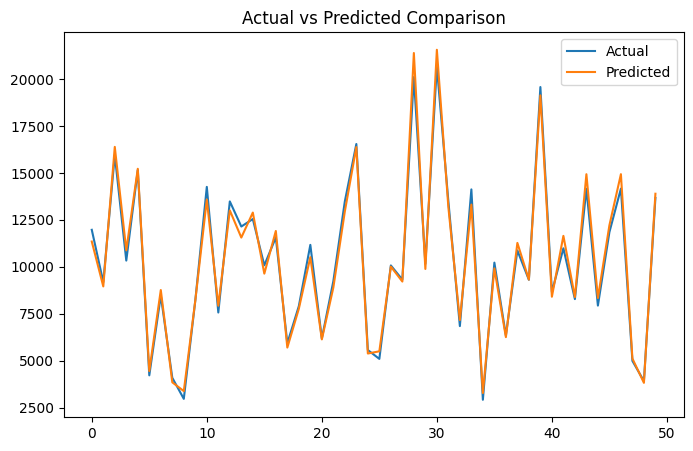

In [64]:
plt.figure(figsize=(8,5))
plt.plot(
    y_test.values[:50],
    label='Actual'
)
plt.plot(
    linear_predictions[:50],
    label='Predicted'
)
plt.legend()
plt.title("Actual vs Predicted Comparison")
plt.show()

This code plots a line graph comparing the actual and predicted delivery values for the first 50 test samples, allowing a visual assessment of the Linear Regression model's prediction accuracy.

In [65]:
from sklearn.model_selection import cross_val_score
validation_scores = cross_val_score(
    baseline_model,
    input_features,
    target_column,
    cv=5,
    scoring='r2'
)
print("Validation Scores:", validation_scores)
print("Average Score:", validation_scores.mean())

Validation Scores: [0.99064904 0.99046596 0.98949293 0.990511   0.99080588]
Average Score: 0.9903849607056949


This code performs 5-fold cross-validation on the Linear Regression model using the R² score, then prints the individual validation scores and their average to evaluate the model's overall performance and generalization ability.

In [66]:
search_params = {
    'n_estimators': [80, 120],
    'max_depth': [6, 12, None]
}
forest_model = RandomForestRegressor(random_state=10)
grid_search = GridSearchCV(
    estimator=forest_model,
    param_grid=search_params,
    cv=4
)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=4, estimator=RandomForestRegressor(random_state=10),
             param_grid={'max_depth': [6, 12, None], 'n_estimators': [80, 120]})

This code defines a hyperparameter grid, initializes a Random Forest Regressor, and uses GridSearchCV with 4-fold cross-validation to find the best combination of hyperparameters by training the model on the training data.

In [67]:
print("Best Hyperparameters:", grid_search.best_params_)

Best Hyperparameters: {'max_depth': None, 'n_estimators': 80}


This code prints the best hyperparameter combination identified by GridSearchCV for the Random Forest model.

In [68]:
best_rf = grid_search.best_estimator_
rf_pred = best_rf.predict(X_test)
print(
    r2_score(y_test,rf_pred)
)

0.9902890108175867


This code retrieves the best Random Forest model from GridSearchCV, uses it to predict the test data, and prints the R² score to evaluate its prediction performance.

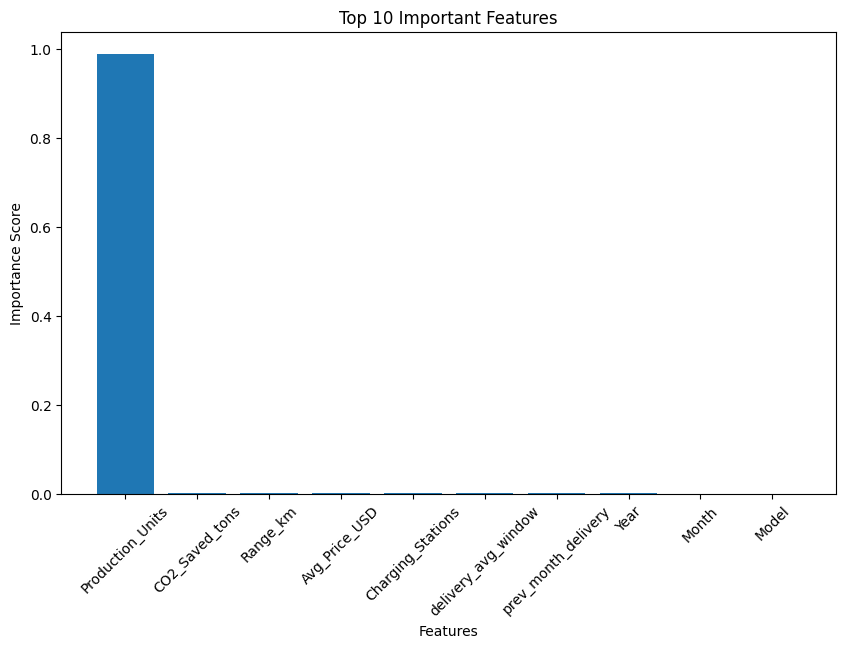

In [69]:
feature_scores = pd.DataFrame({
    'Feature': input_features.columns,
    'Importance': best_rf.feature_importances_
})
top_10_features = feature_scores.sort_values(
    by='Importance',
    ascending=False
).head(10)
plt.figure(figsize=(10,6))
plt.bar(
    top_10_features['Feature'],
    top_10_features['Importance']
)
plt.xticks(rotation=45)
plt.title("Top 10 Important Features")
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.show()

This code calculates the feature importance scores from the trained Random Forest model, selects the top 10 most important features, and visualizes them using a bar chart to identify the features that contribute most to the predictions.

In [70]:
print(df['Production_Units'].corr(df['Estimated_Deliveries']))

0.9942343488939529


This code calculates and prints the Pearson correlation coefficient between Production_Units and Estimated_Deliveries to measure the strength and direction of their linear relationship.

In [71]:
top_10_features

,Feature,Importance
4,Production_Units,0.990204
8,CO2_Saved_tons,0.002125
7,Range_km,0.001180
5,Avg_Price_USD,0.001122
10,Charging_Stations,0.000957
12,delivery_avg_window,0.000938
11,prev_month_delivery,0.000859
0,Year,0.000788
1,Month,0.000664
3,Model,0.000375


This code displays the top 10 most important features ranked by their importance scores as determined by the trained Random Forest model.

In [72]:
from statsmodels.tsa.stattools import adfuller

adf_output = adfuller(
    df['Estimated_Deliveries']
)
print("ADF Statistic:", adf_output[0])
print("P-value:", adf_output[1])

ADF Statistic: -53.82661259715622
P-value: 0.0


This code performs the Augmented Dickey-Fuller (ADF) test on the Estimated_Deliveries time series and prints the ADF statistic and p-value to determine whether the series is stationary.

In [73]:
if adf_output[1] < 0.05:
    print("The delivery trend is stationary")
else:
    print("The delivery trend is non-stationary")

The delivery trend is stationary


This code checks the ADF test p-value to determine whether the Estimated_Deliveries time series is stationary or non-stationary, and prints the corresponding result.

In [74]:
forecast_summary = pd.DataFrame({
    'Actual_Values': y_test.values,
    'Predicted_Values': rf_pred
})
forecast_summary['Prediction_Error'] = (
    forecast_summary['Actual_Values']
    -
    forecast_summary['Predicted_Values']
)
forecast_summary.head(20)

,Actual_Values,Predicted_Values,Prediction_Error
0,11974,11225.9375,748.0625
1,9189,9033.9500,155.0500
2,15956,16808.3500,-852.3500
3,10336,10894.6375,-558.6375
4,15152,15709.4000,-557.4000
5,4224,3963.2375,260.7625
6,8475,8872.9500,-397.9500
7,4093,3829.5000,263.5000
8,2972,3127.2500,-155.2500
9,8208,8099.9500,108.0500


This code creates a forecast summary table containing the actual values, predicted values, and prediction errors (actual − predicted), then displays the first 20 rows for model performance analysis.

**Conclusion**
The project successfully performed the analysis and prediction of estimated Tesla deliveries using data preprocessing, EDA, feature engineering, and machine learning algorithms. The visuals helped in identifying several key trends, distribution, and relations between the variables. The creation of additional features, like the number of deliveries from the last month and 3-month rolling average, made the dataset more suitable for predictions. As the baseline Linear Regression algorithm was created and tested on the metrics of MAE, RMSE, R² Score, and cross-validation, the Random Forest Regressor model, tuned through GridSearchCV, performed better. Moreover, the feature importance helped to identify the most significant parameters influencing the number of deliveries, and the Augmented Dickey-Fuller test checked the stationarity of the delivery trend.